# ReLU activation in the hidden layers — NNFS Chapter 4

In the previous sections we:

- Looked at **single** ReLU neurons ($y = \max(0, wx + b)$),
- Saw how a **pair** of ReLU neurons can create an *activation + deactivation* region,
- Used ReLU networks to approximate nonlinear functions like $y = \sin(x)$.

This section in the book talks about a network with **2 hidden layers of 8 neurons each**, where
each *pair* of neurons (one in each hidden layer) controls a small **area of effect** of the output.

The big picture:

- Hidden layers use **ReLU** (nonlinear),
- Output layer is **linear**,
- With enough ReLU neurons, we can build a **piecewise linear** approximation of $\\sin(x)$,
- Each ReLU (or pair of ReLUs) affects only a **local region** of the input space.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def setup_axes(title=None):
    """Utility to add axes lines and grid, similar to the book's style."""
    plt.axhline(0)
    plt.axvline(0)
    if title is not None:
        plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)

def f_target(x):
    """Target function: y = sin(x)."""
    return np.sin(x)

## 1. Define a 2-hidden-layer ReLU network (1, 8, 8, 1)

We build a small fully-connected network:

- Input dimension: 1
- Hidden layer 1: 8 neurons with ReLU
- Hidden layer 2: 8 neurons with ReLU
- Output layer: 1 neuron, **linear** activation

This matches the structure described in the book (2 hidden layers of 8 neurons each).

In [2]:
rng = np.random.default_rng(42)

n_hidden = 8

# Layer 1: 1 -> 8
W1 = rng.normal(scale=0.5, size=(1, n_hidden))
b1 = np.zeros(n_hidden)

# Layer 2: 8 -> 8
W2 = rng.normal(scale=0.5, size=(n_hidden, n_hidden))
b2 = np.zeros(n_hidden)

# Output layer: 8 -> 1
W3 = rng.normal(scale=0.5, size=(n_hidden, 1))
b3 = np.zeros(1)

def forward_full(x):
    """Forward pass through the full (1, 8, 8, 1) ReLU network.
    
    x: shape (n_samples, 1)
    returns: y_pred of shape (n_samples, 1) and intermediate activations
    """
    z1 = x @ W1 + b1          # (n, 8)
    a1 = relu(z1)             # (n, 8)
    z2 = a1 @ W2 + b2         # (n, 8)
    a2 = relu(z2)             # (n, 8)
    y_pred = a2 @ W3 + b3     # (n, 1)
    return y_pred, (z1, a1, z2, a2)

## 2. Train the network to fit $y = \sin(x)$

We use a simple gradient descent loop on mean squared error (MSE).

This corresponds to the book's idea: after hand-tuning the pairs of neurons, we
can let an optimizer polish the fit further. Here we skip the manual tuning and
let the optimizer do the whole job, but the structure is the same.

In [3]:
# Training data
x_train = np.linspace(-np.pi, np.pi, 256).reshape(-1, 1)
y_train = f_target(x_train)

learning_rate = 0.01
epochs = 4000

for epoch in range(epochs):
    # Forward pass
    y_pred, (z1, a1, z2, a2) = forward_full(x_train)
    
    # Loss (mean squared error)
    error = y_pred - y_train
    loss = np.mean(error**2)
    
    # Gradient of loss w.r.t y_pred
    dL_dy = 2 * error / len(x_train)  # (n, 1)
    
    # Backprop into W3, b3, and a2
    dL_dW3 = a2.T @ dL_dy             # (8, 1)
    dL_db3 = np.sum(dL_dy, axis=0)    # (1,)
    dL_da2 = dL_dy @ W3.T             # (n, 8)
    
    # Backprop through ReLU of layer 2
    relu_grad_z2 = (z2 > 0).astype(float)
    dL_dz2 = dL_da2 * relu_grad_z2    # (n, 8)
    
    dL_dW2 = a1.T @ dL_dz2            # (8, 8)
    dL_db2 = np.sum(dL_dz2, axis=0)   # (8,)
    dL_da1 = dL_dz2 @ W2.T            # (n, 8)
    
    # Backprop through ReLU of layer 1
    relu_grad_z1 = (z1 > 0).astype(float)
    dL_dz1 = dL_da1 * relu_grad_z1    # (n, 8)
    
    dL_dW1 = x_train.T @ dL_dz1       # (1, 8)
    dL_db1 = np.sum(dL_dz1, axis=0)   # (8,)
    
    # Gradient descent update
    W3 -= learning_rate * dL_dW3
    b3 -= learning_rate * dL_db3
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, loss = {loss:.5f}")

Epoch 1000/4000, loss = 0.08681
Epoch 2000/4000, loss = 0.01454
Epoch 3000/4000, loss = 0.00492
Epoch 4000/4000, loss = 0.00304


## 3. Visualize the learned approximation

We now plot the trained network's output against the true $\\sin(x)$ curve.

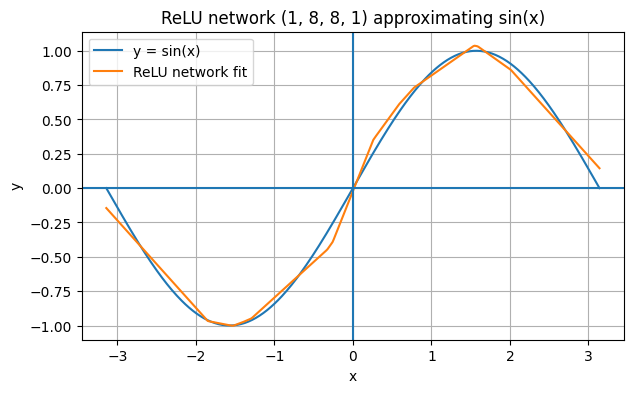

In [4]:
# Dense grid for plotting
x_plot = np.linspace(-np.pi, np.pi, 400).reshape(-1, 1)
y_true = f_target(x_plot)
y_fit, _ = forward_full(x_plot)

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_true, label="y = sin(x)")
plt.plot(x_plot, y_fit, label="ReLU network fit")
setup_axes("ReLU network (1, 8, 8, 1) approximating sin(x)")
plt.legend()
plt.show()

## 4. Inspect "areas of effect" of individual neuron pairs

In the book, they talk about **pairs** of neurons (one from each hidden layer)
that control local **segments** of the curve.

To mimic that idea, we can:

- Take the trained network,
- For a chosen index `k`:
  - Keep only the **k-th neuron** in the first hidden layer,
  - Keep only the **k-th neuron** in the second hidden layer,
  - Keep only the output weight coming from that neuron,
- Set all other connections to zero.

Then we see how much that *single pair* contributes to the final curve.

In [5]:
def forward_single_pair(x, k):
    """Forward pass using only pair k (neuron k in each hidden layer).

    - All other hidden neurons are "disconnected" by zeroing their weights.
    """
    x = np.array(x).reshape(-1, 1)
    
    # First layer: only neuron k is active
    z1_full = x @ W1 + b1          # (n, 8)
    a1_full = relu(z1_full)
    a1 = np.zeros_like(a1_full)
    a1[:, k] = a1_full[:, k]       # keep only neuron k
    
    # Second layer: only neuron k, taking input from neuron k of layer 1
    z2_full = a1 @ W2 + b2         # (n, 8)
    a2_full = relu(z2_full)
    a2 = np.zeros_like(a2_full)
    a2[:, k] = a2_full[:, k]
    
    # Output: only connection from neuron k of layer 2
    W3_pair = np.zeros_like(W3)
    W3_pair[k, 0] = W3[k, 0]
    y_pair = a2 @ W3_pair + b3
    return y_pair

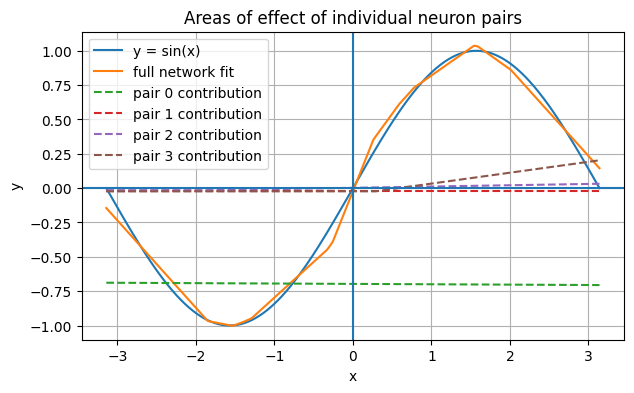

In [6]:
# Plot contributions from a few different pairs

x_plot = np.linspace(-np.pi, np.pi, 400).reshape(-1, 1)
y_true = f_target(x_plot)
y_fit, _ = forward_full(x_plot)

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_true, label="y = sin(x)")
plt.plot(x_plot, y_fit, label="full network fit")

for k in [0, 1, 2, 3]:
    y_k = forward_single_pair(x_plot, k)
    plt.plot(x_plot, y_k, linestyle="--", label=f"pair {k} contribution")

setup_axes("Areas of effect of individual neuron pairs")
plt.legend()
plt.show()

You should see that:

- The **full network fit** tracks $\\sin(x)$ reasonably well.
- Each **pair's contribution** is mostly active in some **local region** of $x$,
  similar to the "areas of effect" described in the book for each pair of neurons.

The book walks through hand-tuning pairs one by one to sculpt the sine curve.
Here, we let the optimizer learn the parameters, but the underlying idea is the same:

- More ReLU neurons $\Rightarrow$ more local "segments" we can shape,
- Two or more hidden layers $\Rightarrow$ richer ways to combine those segments,
- Nonlinear ReLU activation $\Rightarrow$ ability to approximate nonlinear functions like $\\sin(x)$.

You can play with:

- The number of hidden neurons (increase above 8),
- The number of training epochs,
- The learning rate,
- Which pair indices you visualize in `forward_single_pair`. 